<a href="https://colab.research.google.com/github/Mell03y/Mell03y/blob/main/VB_YZ_Ders16_2_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
veri = pd.read_csv("/content/Ders_16_eticaret_iade.csv")

In [3]:
veri.head()

,kategori,urun_fiyati,indirim_orani,sepetteki_urun_sayisi,beden_tablosuna_bakti,onceki_siparis_sayisi,onceki_iade_orani,musteri_yasi,urun_puani,teslimat_suresi_gun,odeme_yontemi,kampanya_gunu,siparis_saati,iade_edildi
0,Ev,560.0,0.2,2,0,0,NaN,NaN,3.8,2,Kapida odeme,0,2,0
1,Ayakkabi,710.0,0.2,3,0,1,0.20,54.0,3.3,3,Kapida odeme,0,22,1
2,Ev,1650.0,0.2,1,0,9,0.09,24.0,NaN,2,Kapida odeme,0,13,1
3,Ev,2680.0,0.0,2,0,15,0.04,34.0,4.1,4,Kart,0,2,0
4,Giyim,520.0,0.0,2,1,1,0.12,30.0,4.2,5,Kart,0,9,0


In [5]:
veri.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   kategori               4000 non-null   object 
 1   urun_fiyati            4000 non-null   float64
 2   indirim_orani          4000 non-null   float64
 3   sepetteki_urun_sayisi  4000 non-null   int64  
 4   beden_tablosuna_bakti  4000 non-null   int64  
 5   onceki_siparis_sayisi  4000 non-null   int64  
 6   onceki_iade_orani      3474 non-null   float64
 7   musteri_yasi           3513 non-null   float64
 8   urun_puani             3449 non-null   float64
 9   teslimat_suresi_gun    4000 non-null   int64  
 10  odeme_yontemi          4000 non-null   object 
 11  kampanya_gunu          4000 non-null   int64  
 12  siparis_saati          4000 non-null   int64  
 13  iade_edildi            4000 non-null   int64  
dtypes: float64(5), int64(7), object(2)
memory usage: 437.6+ 

In [10]:
veri.isnull().sum()
print("Eksik Oranları:")
print(veri.isnull().mean() * 100)

Eksik Oranları:
kategori                  0.000
urun_fiyati               0.000
indirim_orani             0.000
sepetteki_urun_sayisi     0.000
beden_tablosuna_bakti     0.000
onceki_siparis_sayisi     0.000
onceki_iade_orani        13.150
musteri_yasi             12.175
urun_puani               13.775
teslimat_suresi_gun       0.000
odeme_yontemi             0.000
kampanya_gunu             0.000
siparis_saati             0.000
iade_edildi               0.000
dtype: float64


In [12]:
veri['iade_edildi'].value_counts()

,count
iade_edildi,
0,2834
1,1166


In [14]:
veri['iade_edildi'].value_counts(normalize=True) #siparişlerin %29.15 i iade edilmiş.

,proportion
iade_edildi,
0,0.7085
1,0.2915


Text(0, 0.5, 'İade Oranı')

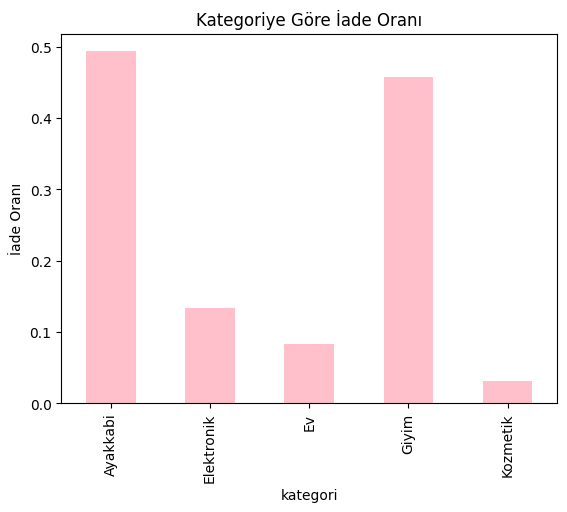

In [21]:
veri.groupby('kategori')['iade_edildi'].mean().plot(kind='bar', color='pink')

plt.title('Kategoriye Göre İade Oranı')
plt.ylabel('İade Oranı')


In [23]:
veri.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   kategori               4000 non-null   object 
 1   urun_fiyati            4000 non-null   float64
 2   indirim_orani          4000 non-null   float64
 3   sepetteki_urun_sayisi  4000 non-null   int64  
 4   beden_tablosuna_bakti  4000 non-null   int64  
 5   onceki_siparis_sayisi  4000 non-null   int64  
 6   onceki_iade_orani      3474 non-null   float64
 7   musteri_yasi           3513 non-null   float64
 8   urun_puani             3449 non-null   float64
 9   teslimat_suresi_gun    4000 non-null   int64  
 10  odeme_yontemi          4000 non-null   object 
 11  kampanya_gunu          4000 non-null   int64  
 12  siparis_saati          4000 non-null   int64  
 13  iade_edildi            4000 non-null   int64  
dtypes: float64(5), int64(7), object(2)
memory usage: 437.6+ 

In [26]:
veri_model = pd.get_dummies(veri, columns=['kategori',"odeme_yontemi"], drop_first=True,dtype=int)
veri_model.head()



,urun_fiyati,indirim_orani,sepetteki_urun_sayisi,beden_tablosuna_bakti,onceki_siparis_sayisi,onceki_iade_orani,musteri_yasi,urun_puani,teslimat_suresi_gun,kampanya_gunu,siparis_saati,iade_edildi,kategori_Elektronik,kategori_Ev,kategori_Giyim,kategori_Kozmetik,odeme_yontemi_Kart
0,560.0,0.2,2,0,0,NaN,NaN,3.8,2,0,2,0,0,1,0,0,0
1,710.0,0.2,3,0,1,0.20,54.0,3.3,3,0,22,1,0,0,0,0,0
2,1650.0,0.2,1,0,9,0.09,24.0,NaN,2,0,13,1,0,1,0,0,0
3,2680.0,0.0,2,0,15,0.04,34.0,4.1,4,0,2,0,0,1,0,0,1
4,520.0,0.0,2,1,1,0.12,30.0,4.2,5,0,9,0,0,0,1,0,1


In [28]:
X = veri_model.drop('iade_edildi', axis=1)
y = veri_model['iade_edildi']
print(X.shape)


(4000, 16)


In [30]:
# Train ve Test olarak ayırma
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)

(3200, 16)
(800, 16)


In [36]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
xgb_varsayılan = XGBClassifier(random_state=42)
xgb_varsayılan.fit(X_train, y_train)
y_pred = xgb_varsayılan.predict(X_test)



In [38]:
print('Eğitim dogruluk', xgb_varsayılan.score(X_train, y_train))
print('Test dogruluk', xgb_varsayılan.score(X_test, y_test))
print('Accuracy:', accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Eğitim dogruluk 0.9975
Test dogruluk 0.78375
Accuracy: 0.78375
[[491  67]
 [106 136]]
              precision    recall  f1-score   support

           0       0.82      0.88      0.85       558
           1       0.67      0.56      0.61       242

    accuracy                           0.78       800
   macro avg       0.75      0.72      0.73       800
weighted avg       0.78      0.78      0.78       800

